In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_dir = '/content/drive/MyDrive/Project dataset/archive/Combined Dataset/train'
test_dir = '/content/drive/MyDrive/Project dataset/archive/Combined Dataset/test'

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training',
)

validation_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
)


Found 8192 images belonging to 4 classes.
Found 2048 images belonging to 4 classes.
Found 1279 images belonging to 4 classes.


In [ ]:
%pip install keras-tuner


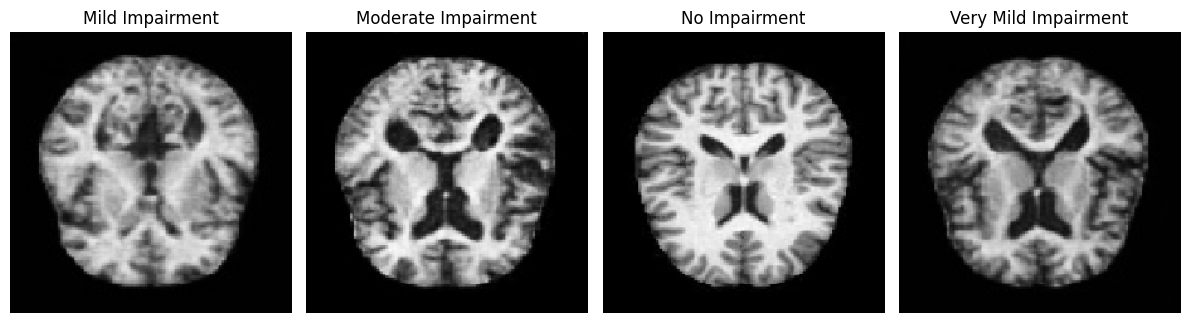

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


class_indices = train_generator.class_indices
class_names = list(class_indices.keys())

plt.figure(figsize=(12, 6))

for class_name in class_names:
    for batch_images, batch_labels in train_generator:
        class_index = class_indices[class_name]

        for i, label in enumerate(batch_labels):
            if np.argmax(label) == class_index:
                image = batch_images[i]
                break
        else:
            continue
        break

    plt.subplot(1, len(class_names), class_index + 1)
    plt.imshow(image)
    plt.title(class_name)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import cv2
from skimage import exposure, morphology,filters, segmentation

train_dir = '/content/drive/MyDrive/Project dataset/archive/Combined Dataset/train'
test_dir = '/content/drive/MyDrive/Project dataset/archive/Combined Dataset/test'

def crop_img(img):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    gray = cv2.GaussianBlur(gray, (3, 3), 0)
    thresh = cv2.threshold(gray, 45, 255, cv2.THRESH_BINARY)[1]
    thresh = cv2.erode(thresh, None, iterations=2)
    thresh = cv2.dilate(thresh, None, iterations=2)

    thresh = thresh.astype('uint8')
    cnts, _ = cv2.findContours(thresh.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if cnts:
        c = max(cnts, key=cv2.contourArea)
        extLeft = tuple(c[c[:, :, 0].argmin()][0])
        extRight = tuple(c[c[:, :, 0].argmax()][0])
        extTop = tuple(c[c[:, :, 1].argmin()][0])
        extBot = tuple(c[c[:, :, 1].argmax()][0])

        ADD_PIXELS = 0
        new_img = img[extTop[1]-ADD_PIXELS:extBot[1]+ADD_PIXELS, extLeft[0]-ADD_PIXELS:extRight[0]+ADD_PIXELS].copy()
    else:
        new_img = img.copy()

    return new_img

def preprocess_image(image):
    image = crop_img(image)

    image = image.astype('float32') / 255.0
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    equalized = exposure.equalize_adapthist(gray)

    blurred = cv2.GaussianBlur(equalized, (5, 5), 0)

    blurred_uint8 = (blurred * 255).astype(np.uint8)
    _, thresholded = cv2.threshold(blurred_uint8, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    kernel = np.ones((5, 5), np.uint8)
    dilated = cv2.dilate(thresholded, kernel, iterations=2)

    contours, _ = cv2.findContours(dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    min_contour_area = 100
    filtered_contours = [cnt for cnt in contours if cv2.contourArea(cnt) > min_contour_area]

    mask = np.zeros_like(gray)
    cv2.drawContours(mask, filtered_contours, -1, (255), thickness=cv2.FILLED)

    mask = mask.astype(np.uint8)
    masked_image = cv2.bitwise_and(image, image, mask=mask)

    masked_image_gray = cv2.cvtColor(masked_image, cv2.COLOR_BGR2GRAY)

    contrast_enhanced = cv2.equalizeHist((masked_image_gray * 255).astype(np.uint8))

    low_contrast = cv2.addWeighted(contrast_enhanced, 0.75, np.zeros_like(contrast_enhanced), 0.98, 0)
    reduced_contrast = cv2.addWeighted(contrast_enhanced, 0.75, low_contrast, 0.25, 0)

    gaussian_blurred = cv2.GaussianBlur(reduced_contrast, (9, 9), 15.0)
    sharpened = cv2.addWeighted(reduced_contrast, 1.5, gaussian_blurred, -0.7, 0)

    sharpened_rgb = cv2.cvtColor(sharpened, cv2.COLOR_GRAY2RGB)

    resized_image = cv2.resize(sharpened_rgb, (224, 224))

    return resized_image

train_datagen = ImageDataGenerator(
    preprocessing_function = preprocess_image,
    validation_split=0.2,
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=16,
    class_mode='categorical',
    subset='training',
)

validation_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=16,
    class_mode='categorical',
    subset='validation',
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=16,
    class_mode='categorical',
)


Found 8192 images belonging to 4 classes.
Found 2048 images belonging to 4 classes.
Found 1279 images belonging to 4 classes.


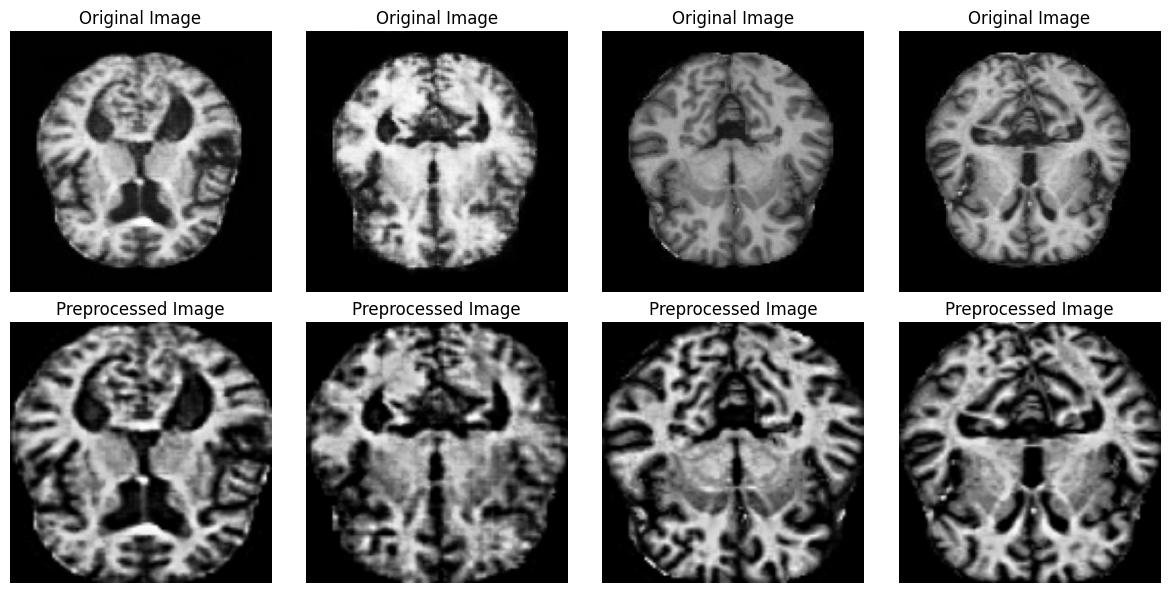

In [ ]:
import os
from tensorflow.keras.preprocessing.image import load_img, img_to_array

def visualize_preprocessing(image_paths):
    plt.figure(figsize=(12, 6))
    for i, image_path in enumerate(image_paths):
        original_image = load_img(image_path)
        original_image_array = img_to_array(original_image)
        preprocessed_image = preprocess_image(original_image_array)
        plt.subplot(2, len(image_paths), i + 1)
        plt.imshow(cv2.cvtColor(original_image_array.astype('uint8'), cv2.COLOR_RGB2BGR))
        plt.title('Original Image')
        plt.axis('off')
        plt.subplot(2, len(image_paths), i + 1 + len(image_paths))
        plt.imshow(cv2.cvtColor(preprocessed_image.astype('uint8'), cv2.COLOR_RGB2BGR))
        plt.title('Preprocessed Image')
        plt.axis('off')
    plt.tight_layout()
    plt.show()

test_image_dir = train_dir
test_image_paths = [os.path.join(test_image_dir, class_name, os.listdir(os.path.join(test_image_dir, class_name))[0]) for class_name in class_names]
visualize_preprocessing(test_image_paths)


#**Custom CNN Model**

In [ ]:
from tensorflow.keras.layers import BatchNormalization, Conv2D, MaxPooling2D, Flatten, Dropout, Dense
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
from kerastuner import HyperModel, RandomSearch
from tensorflow.keras.regularizers import l2
import math
# Define callbacks
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6)
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
checkpoint = ModelCheckpoint('/content/drive/MyDrive/Project dataset/best_model_custom_cnn.h5', monitor='val_accuracy', save_best_only=True, mode='max')


# Custom CNN HyperModel
class CustomCNNHyperModel(HyperModel):
    def build(self, hp):
        model = Sequential()

        model.add(Conv2D(
            hp.Int('conv1_filters', min_value=32, max_value=64, step=32),
            (3, 3),
            activation='relu',
            input_shape=(224, 224, 3),
            kernel_regularizer=l2(hp.Float('l2_regularizer', min_value=1e-5, max_value=1e-2, sampling='LOG'))
        ))
        model.add(BatchNormalization())
        model.add(MaxPooling2D((2, 2)))
        model.add(Dropout(hp.Float('dropout1', min_value=0.2, max_value=0.5, step=0.1)))

        model.add(Conv2D(
            hp.Int('conv2_filters', min_value=64, max_value=128, step=64),
            (3, 3),
            activation='relu',
            kernel_regularizer=l2(hp.Float('l2_regularizer', min_value=1e-5, max_value=1e-2, sampling='LOG'))
        ))
        model.add(BatchNormalization())
        model.add(MaxPooling2D((2, 2)))
        model.add(Dropout(hp.Float('dropout2', min_value=0.2, max_value=0.5, step=0.1)))

        model.add(Conv2D(
            hp.Int('conv3_filters', min_value=128, max_value=256, step=128),
            (3, 3),
            activation='relu',
            kernel_regularizer=l2(hp.Float('l2_regularizer', min_value=1e-5, max_value=1e-2, sampling='LOG'))
        ))
        model.add(BatchNormalization())
        model.add(MaxPooling2D((2, 2)))
        model.add(Dropout(hp.Float('dropout3', min_value=0.2, max_value=0.5, step=0.1)))

        model.add(Flatten())
        model.add(Dense(
            hp.Int('units', min_value=128, max_value=512, step=128),
            activation='relu',
            kernel_regularizer=l2(hp.Float('l2_regularizer', min_value=1e-5, max_value=1e-2, sampling='LOG'))
        ))
        model.add(BatchNormalization())
        model.add(Dropout(hp.Float('dropout4', min_value=0.2, max_value=0.5, step=0.1)))
        model.add(Dense(4, activation='softmax'))

        model.compile(
            optimizer=Adam(learning_rate=hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])),
            loss='categorical_crossentropy',
            metrics=['accuracy']
        )
        return model

# Hyperparameter tuning
tuner_custom_cnn = RandomSearch(
    CustomCNNHyperModel(),
    objective='val_accuracy',
    max_trials=30,
    executions_per_trial=1,
    directory='/content/drive/MyDrive/Project dataset/archive',
    project_name='custom_cnn_tuning'
)

tuner_custom_cnn.search(
    train_generator,
    epochs=50,
    validation_data=validation_generator,
    callbacks=[reduce_lr, early_stop, checkpoint],
    batch_size= 16
)

# Retrieve the best model
best_cnn_model = tuner_custom_cnn.get_best_models(num_models=1)[0]

Trial 2 Complete [00h 56m 26s]
val_accuracy: 0.8173828125

Best val_accuracy So Far: 0.8173828125
Total elapsed time: 01h 14m 02s

Search: Running Trial #3

Value             |Best Value So Far |Hyperparameter
32                |32                |conv1_filters
0.00020268        |1.0285e-05        |l2_regularizer
0.2               |0.4               |dropout1
128               |64                |conv2_filters
0.4               |0.2               |dropout2
256               |256               |conv3_filters
0.2               |0.2               |dropout3
512               |384               |units
0.2               |0.2               |dropout4
0.0001            |0.01              |learning_rate

Epoch 1/50
  6/512 [..............................] - ETA: 1:09 - loss: 2.0654 - accuracy: 0.5104

512/512 [==============================] - 140s 264ms/step - loss: 0.7354 - accuracy: 0.8259 - val_loss: 1.7860 - val_accuracy: 0.5464 - lr: 1.0000e-04
Epoch 2/50
512/512 [==============================] - 138s 269ms/step - loss: 0.4607 - accuracy: 0.9240 - val_loss: 1.4789 - val_accuracy: 0.6665 - lr: 1.0000e-04
Epoch 3/50
512/512 [==============================] - 128s 250ms/step - loss: 0.3877 - accuracy: 0.9542 - val_loss: 1.6475 - val_accuracy: 0.6406 - lr: 1.0000e-04
Epoch 4/50
512/512 [==============================] - 137s 267ms/step - loss: 0.3408 - accuracy: 0.9668 - val_loss: 1.2957 - val_accuracy: 0.7148 - lr: 1.0000e-04
Epoch 5/50
512/512 [==============================] - 141s 275ms/step - loss: 0.3308 - accuracy: 0.9701 - val_loss: 1.2821 - val_accuracy: 0.7241 - lr: 1.0000e-04
Epoch 6/50
512/512 [==============================] - ETA: 0s - loss: 0.2989 - accuracy: 0.9811

KeyboardInterrupt: 

In [ ]:
tuner_custom_cnn.search_space_summary()


In [ ]:
tuner_custom_cnn.results_summary()


In [ ]:
best_trial = tuner_custom_cnn.oracle.get_best_trials(num_trials=1)[0]

print("Hyperparameters of the best CNN model:")
print(best_trial.hyperparameters.values)

Hyperparameters of the best CNN model:
{'l2_regularization': 0.002164599863434296, 'conv1_filters': 32, 'dropout1': 0.30000000000000004, 'conv2_filters': 64, 'dropout2': 0.2, 'conv3_filters': 256, 'dropout3': 0.2, 'units': 512, 'dropout4': 0.30000000000000004, 'learning_rate': 0.0001}


In [ ]:
from tensorflow.keras.utils import plot_model
best_cnn_model.summary()


In [ ]:
plot_model(best_cnn_model, to_file='/content/drive/MyDrive/Project dataset/archive/best_model_architecture.jpg', show_shapes=True, show_layer_names=True)

from IPython.display import Image
Image(filename='/content/drive/MyDrive/Project dataset/archive/best_model_architecture.jpg')

In [ ]:
history = best_cnn_model.fit(
    train_generator,
    epochs=50,
    validation_data=validation_generator,
    callbacks=[reduce_lr, early_stop, checkpoint]
)


Epoch 1/50
256/256 [==============================] - ETA: 0s - loss: 0.0417 - accuracy: 0.9855 

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


256/256 [==============================] - 8576s 33s/step - loss: 0.0417 - accuracy: 0.9855 - val_loss: 1.0562 - val_accuracy: 0.7681 - lr: 2.0000e-04
Epoch 2/50
256/256 [==============================] - 48s 180ms/step - loss: 0.0384 - accuracy: 0.9862 - val_loss: 1.0130 - val_accuracy: 0.7812 - lr: 2.0000e-04
Epoch 3/50
256/256 [==============================] - 49s 188ms/step - loss: 0.0360 - accuracy: 0.9888 - val_loss: 0.8151 - val_accuracy: 0.7959 - lr: 2.0000e-04
Epoch 4/50
256/256 [==============================] - 48s 186ms/step - loss: 0.0291 - accuracy: 0.9906 - val_loss: 0.8744 - val_accuracy: 0.8008 - lr: 2.0000e-04
Epoch 5/50
256/256 [==============================] - 43s 164ms/step - loss: 0.0312 - accuracy: 0.9883 - val_loss: 0.8126 - val_accuracy: 0.8003 - lr: 2.0000e-04
Epoch 6/50
256/256 [==============================] - 42s 164ms/step - loss: 0.0264 - accuracy: 0.9907 - val_loss: 0.8720 - val_accuracy: 0.7925 - lr: 2.0000e-04
Epoch 7/50
256/256 [===================

## **Evaluate the CNN model on the test data**

In [ ]:
test_loss, test_accuracy = best_cnn_model.evaluate(test_generator, verbose=2)
print(f'Test Loss: {test_loss}')
print(f'Test Accuracy: {test_accuracy}')


40/40 - 4s - loss: 0.3630 - accuracy: 0.9023 - 4s/epoch - 99ms/step
Test Loss: 0.36301445960998535
Test Accuracy: 0.9022673964500427


In [ ]:
best_cnn_model.save('/content/drive/MyDrive/Project dataset/archive/best_model_custom_cnn_final.h5')


/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [ ]:

def predict_and_visualize(image_path, model, class_names):
    image = load_img(image_path, target_size=(224, 224))
    image_array = img_to_array(image) / 255.0
    image_array = np.expand_dims(image_array, axis=0)

    prediction = model.predict(image_array)
    predicted_class_index = np.argmax(prediction)
    predicted_class_name = class_names[predicted_class_index]

    plt.figure(figsize=(6, 6))
    plt.imshow(image)
    plt.title(f"Predicted Class: {predicted_class_name}")
    plt.axis('off')
    plt.show()

class_indices = train_generator.class_indices
class_names = list(class_indices.keys())

test_image_paths = [
    '/content/drive/MyDrive/Project dataset/archive/Combined Dataset/test/Mild Impairment/1 (10).jpg',
    '/content/drive/MyDrive/Project dataset/archive/Combined Dataset/test/Moderate Impairment/12.jpg',
    '/content/drive/MyDrive/Project dataset/archive/Combined Dataset/test/No Impairment/1 (16).jpg',
    '/content/drive/MyDrive/Project dataset/archive/Combined Dataset/test/Very Mild Impairment/1 (10).jpg',
]

for image_path in test_image_paths:
    predict_and_visualize(image_path, best_cnn_model, class_names)


1/1 [==============================] - 0s 70ms/step
Predicted Class: [0]


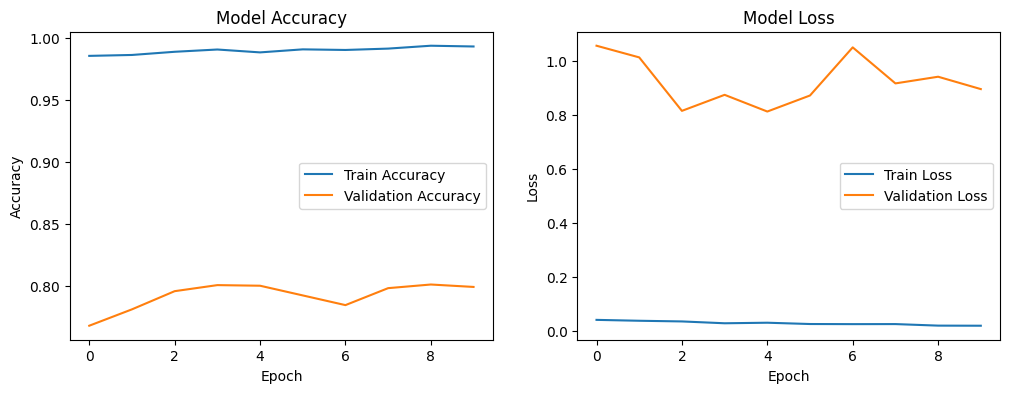

In [ ]:
# Plot training history
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

64/64 [==============================] - 6s 95ms/step


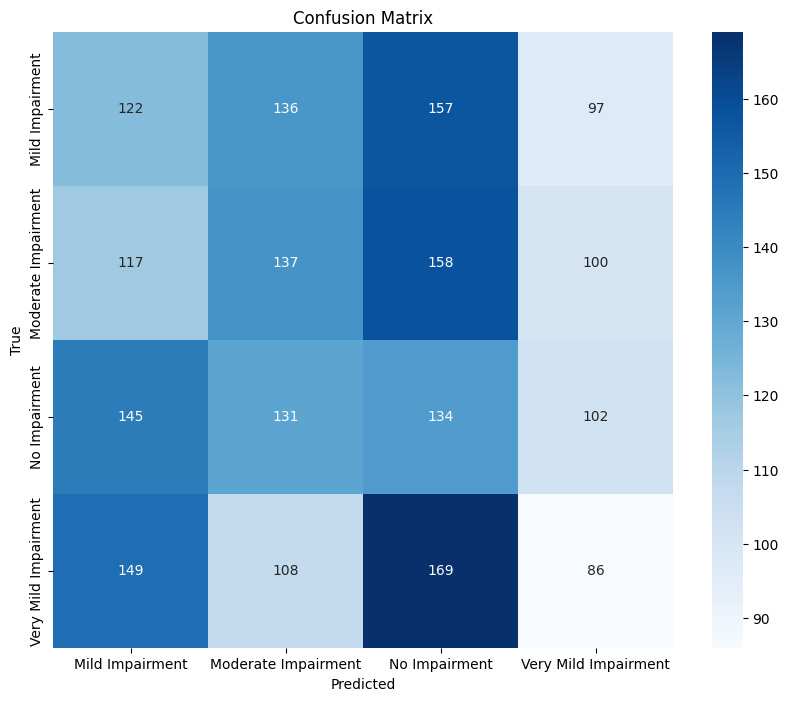

In [ ]:
y_pred = best_cnn_model.predict(validation_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = validation_generator.classes

conf_matrix = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=validation_generator.class_indices, yticklabels=validation_generator.class_indices)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [ ]:
print("Classification Report:")
class_report = classification_report(y_true, y_pred_classes, target_names=list(validation_generator.class_indices.keys()))
print(class_report)

Classification Report:
                      precision    recall  f1-score   support

     Mild Impairment       0.23      0.24      0.23       512
 Moderate Impairment       0.27      0.27      0.27       512
       No Impairment       0.22      0.26      0.24       512
Very Mild Impairment       0.22      0.17      0.19       512

            accuracy                           0.23      2048
           macro avg       0.23      0.23      0.23      2048
        weighted avg       0.23      0.23      0.23      2048



64/64 [==============================] - 6s 96ms/step


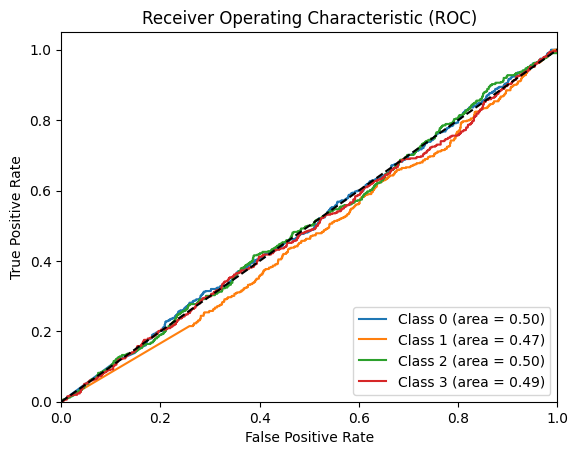

In [ ]:
y_pred_prob = best_cnn_model.predict(validation_generator)
n_classes = len(validation_generator.class_indices)

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true, y_pred_prob[:, i], pos_label=i)
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure()
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (area = {roc_auc[i]:0.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc='lower right')
plt.show()

#**VGG16 model**

In [ ]:
from tensorflow.keras.applications import VGG16

class VGG16HyperModel(HyperModel):
    def build(self, hp):
        base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

        for layer in base_model.layers:
            layer.trainable = False

        x = base_model.output
        x = GlobalAveragePooling2D()(x)
        x = Dense(hp.Int('units1', min_value=128, max_value=512, step=128), activation='relu')(x)
        x = Dropout(hp.Float('dropout1', min_value=0.2, max_value=0.5, step=0.1))(x)

        x = Dense(hp.Int('units2', min_value=128, max_value=512, step=128), activation='relu')(x)
        x = Dropout(hp.Float('dropout2', min_value=0.2, max_value=0.5, step=0.1))(x)

        x = Dense(hp.Int('units3', min_value=128, max_value=512, step=128), activation='relu')(x)
        x = Dropout(hp.Float('dropout3', min_value=0.2, max_value=0.5, step=0.1))(x)

        output = Dense(4, activation='softmax')(x)

        model = Model(inputs=base_model.input, outputs=output)

        model.compile(
            optimizer=Adam(learning_rate=hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])),
            loss='categorical_crossentropy',
            metrics=['accuracy']
        )
        return model

tuner_vgg16 = RandomSearch(
    VGG16HyperModel(),
    objective='val_accuracy',
    max_trials=10,
    executions_per_trial=2,
    directory='my_dir',
    project_name='vgg16_tuning'
)

tuner_vgg16.search(
    train_generator,
    epochs=50,
    validation_data=validation_generator,
    callbacks=[reduce_lr, early_stop, checkpoint]
)

best_vgg16_model = tuner_vgg16.get_best_models(num_models=1)[0]
best_vgg16_model.summary()


#**Resnet50**

In [ ]:
from tensorflow.keras.applications import ResNet50

class ResNet50HyperModel(HyperModel):
    def build(self, hp):
        base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

        for layer in base_model.layers:
            layer.trainable = False

        x = base_model.output
        x = GlobalAveragePooling2D()(x)
        x = Dense(hp.Int('units1', min_value=128, max_value=512, step=128), activation='relu')(x)
        x = Dropout(hp.Float('dropout1', min_value=0.2, max_value=0.5, step=0.1))(x)

        x = Dense(hp.Int('units2', min_value=128, max_value=512, step=128), activation='relu')(x)
        x = Dropout(hp.Float('dropout2', min_value=0.2, max_value=0.5, step=0.1))(x)

        x = Dense(hp.Int('units3', min_value=128, max_value=512, step=128), activation='relu')(x)
        x = Dropout(hp.Float('dropout3', min_value=0.2, max_value=0.5, step=0.1))(x)

        output = Dense(4, activation='softmax')(x)

        model = Model(inputs=base_model.input, outputs=output)

        model.compile(
            optimizer=Adam(learning_rate=hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])),
            loss='categorical_crossentropy',
            metrics=['accuracy']
        )
        return model

tuner_resnet50 = RandomSearch(
    ResNet50HyperModel(),
    objective='val_accuracy',
    max_trials=10,
    executions_per_trial=2,
    directory='my_dir',
    project_name='resnet50_tuning'
)

tuner_resnet50.search(
    train_generator,
    epochs=50,
    validation_data=validation_generator,
    callbacks=[reduce_lr, early_stop, checkpoint]
)

best_resnet50_model = tuner_resnet50.get_best_models(num_models=1)[0]
best_resnet50_model.summary()


#**Densenet201**

In [ ]:
from tensorflow.keras.applications import DenseNet201
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
from keras_tuner import HyperModel, RandomSearch

class DenseNet201HyperModel(HyperModel):
    def build(self, hp):
        base_model = DenseNet201(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

        for layer in base_model.layers:
            layer.trainable = False

        x = base_model.output
        x = GlobalAveragePooling2D()(x)
        x = Dense(hp.Int('units1', min_value=128, max_value=512, step=128), activation='relu')(x)
        x = Dropout(hp.Float('dropout1', min_value=0.2, max_value=0.5, step=0.1))(x)

        x = Dense(hp.Int('units2', min_value=128, max_value=512, step=128), activation='relu')(x)
        x = Dropout(hp.Float('dropout2', min_value=0.2, max_value=0.5, step=0.1))(x)

        x = Dense(hp.Int('units3', min_value=128, max_value=512, step=128), activation='relu')(x)
        x = Dropout(hp.Float('dropout3', min_value=0.2, max_value=0.5, step=0.1))(x)

        output = Dense(4, activation='softmax')(x)

        model = Model(inputs=base_model.input, outputs=output)

        model.compile(
            optimizer=Adam(learning_rate=hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])),
            loss='categorical_crossentropy',
            metrics=['accuracy']
        )
        return model

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6)
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
checkpoint = ModelCheckpoint('best_model_densenet_tune.h5', monitor='val_accuracy', save_best_only=True, mode='max')

tuner_densenet201 = RandomSearch(
    DenseNet201HyperModel(),
    objective='val_accuracy',
    max_trials=10,
    executions_per_trial=2,
    directory='my_dir',
    project_name='densenet201_tuning'
)

tuner_densenet201.search(
    train_generator,
    epochs=50,
    validation_data=validation_generator,
    callbacks=[reduce_lr, early_stop, checkpoint]
)

best_densenet201_model = tuner_densenet201.get_best_models(num_models=1)[0]
best_densenet201_model.summary()
